# Лабораторная работа №4
## Классификация рукописных цифр (MNIST) с помощью MLP и CNN

In [1]:
# Установка необходимых библиотек
!pip install tensorflow scikit-learn matplotlib seaborn

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


## 1. Загрузка датасета MNIST

In [3]:
# Загружаем MNIST напрямую из keras.datasets
# Датасет содержит 70 000 изображений рукописных цифр 28x28 пикселей
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

print("Размер обучающей выборки:", X_train.shape)  # (60000, 28, 28)
print("Размер тестовой выборки:", X_test.shape)    # (10000, 28, 28)
print("Количество классов:", len(np.unique(y_train)))  # 10 цифр (0-9)
print("Диапазон значений пикселей:", X_train.min(), "-", X_train.max())

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Размер обучающей выборки: (60000, 28, 28)
Размер тестовой выборки: (10000, 28, 28)
Количество классов: 10
Диапазон значений пикселей: 0 - 255


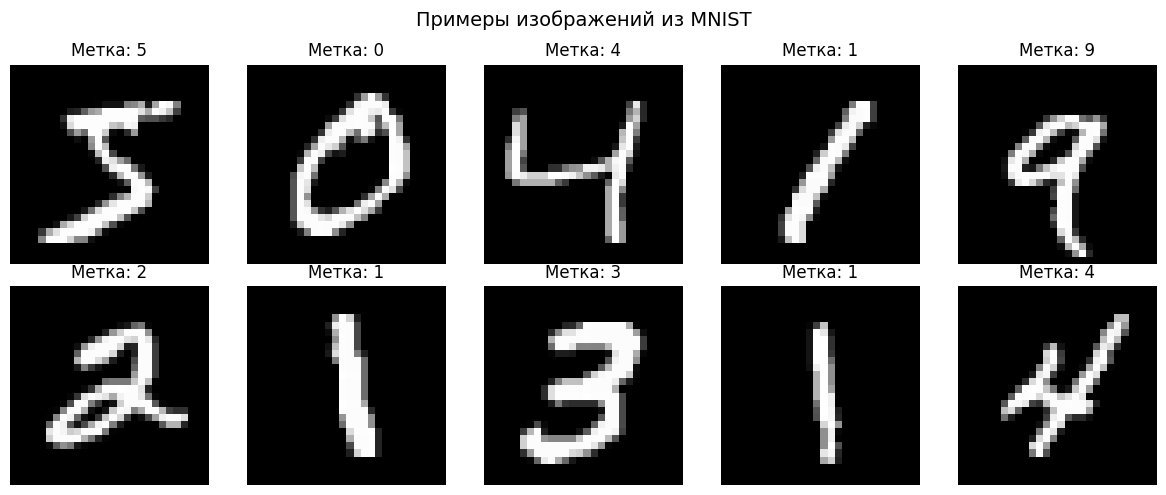

In [4]:
# Визуализация нескольких примеров из датасета
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i], cmap='gray')
    ax.set_title(f"Метка: {y_train[i]}", fontsize=12)
    ax.axis('off')
plt.suptitle("Примеры изображений из MNIST", fontsize=14)
plt.tight_layout()
plt.show()

## 2. Нормализация данных

In [5]:
# Нормализация: приводим значения пикселей из диапазона [0, 255] к [0, 1]
# Это ускоряет обучение и улучшает сходимость градиентного спуска,
# так как все входные значения оказываются в одном масштабе
X_train_norm = X_train.astype('float32') / 255.0
X_test_norm = X_test.astype('float32') / 255.0

print("Диапазон после нормализации:", X_train_norm.min(), "-", X_train_norm.max())

Диапазон после нормализации: 0.0 - 1.0


## 3. Обучение MLP (многослойный перцептрон)

In [6]:
# Для MLP нужно "развернуть" изображение 28x28 в вектор длиной 784
X_train_flat = X_train_norm.reshape(-1, 784)  # (60000, 784)
X_test_flat = X_test_norm.reshape(-1, 784)    # (10000, 784)

print("Форма данных для MLP:", X_train_flat.shape)

Форма данных для MLP: (60000, 784)


In [7]:
# Строим MLP — полносвязную нейронную сеть
# Архитектура: 784 -> 128 (ReLU) -> 64 (ReLU) -> 10 (Softmax)
mlp_model = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation='relu'),   # Первый скрытый слой: 128 нейронов
    layers.Dense(64, activation='relu'),    # Второй скрытый слой: 64 нейрона
    layers.Dense(10, activation='softmax')  # Выходной слой: 10 классов (цифры 0-9)
])

# Компиляция модели:
# - optimizer='adam' — адаптивный оптимизатор, подстраивает learning rate для каждого параметра
# - loss='sparse_categorical_crossentropy' — функция потерь для многоклассовой классификации
#   (sparse означает, что метки — целые числа 0-9, а не one-hot вектора)
# - metrics=['accuracy'] — отслеживаем точность во время обучения
mlp_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

mlp_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Обучаем MLP
# epochs=20 — количество полных проходов по обучающей выборке
# batch_size=128 — размер мини-батча (сколько примеров обрабатывается за один шаг)
# validation_split=0.1 — 10% обучающих данных откладываем для валидации
mlp_history = mlp_model.fit(
    X_train_flat, y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9019 - loss: 0.3493 - val_accuracy: 0.9615 - val_loss: 0.1454
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9562 - loss: 0.1479 - val_accuracy: 0.9685 - val_loss: 0.1088
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9688 - loss: 0.1017 - val_accuracy: 0.9723 - val_loss: 0.0965
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9771 - loss: 0.0761 - val_accuracy: 0.9772 - val_loss: 0.0795
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9815 - loss: 0.0601 - val_accuracy: 0.9772 - val_loss: 0.0777
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9851 - loss: 0.0492 - val_accuracy: 0.9778 - val_loss: 0.0760
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9873 - loss: 0.0408 - val_accuracy: 0.9762 - val_loss: 0.0832
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9901 - loss: 0.0326 - val_accuracy

## 4. Обучение CNN (свёрточная нейронная сеть)

In [9]:
# Для CNN нужно добавить размерность канала: (28, 28) -> (28, 28, 1)
# 1 канал, потому что изображения чёрно-белые (для цветных было бы 3 — RGB)
X_train_cnn = X_train_norm.reshape(-1, 28, 28, 1)
X_test_cnn = X_test_norm.reshape(-1, 28, 28, 1)

print("Форма данных для CNN:", X_train_cnn.shape)

Форма данных для CNN: (60000, 28, 28, 1)


In [10]:
# Строим CNN — свёрточную нейронную сеть
cnn_model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),

    # Первый свёрточный блок:
    # Conv2D(32, (3,3)) — 32 фильтра размером 3x3, извлекают локальные признаки (края, углы)
    # MaxPooling2D — уменьшает пространственные размеры в 2 раза (28x28 -> 14x14)
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Второй свёрточный блок:
    # Conv2D(64, (3,3)) — 64 фильтра, извлекают более сложные признаки (комбинации краёв, текстуры)
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Flatten — разворачивает 2D карту признаков в 1D вектор для полносвязных слоёв
    layers.Flatten(),

    # Полносвязный слой для финальной классификации
    layers.Dense(64, activation='relu'),

    # Выходной слой: 10 классов
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Обучаем CNN с теми же параметрами для честного сравнения
cnn_history = cnn_model.fit(
    X_train_cnn, y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 43s 100ms/step - accuracy: 0.9288 - loss: 0.2555 - val_accuracy: 0.9803 - val_loss: 0.0730
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 43s 102ms/step - accuracy: 0.9796 - loss: 0.0647 - val_accuracy: 0.9837 - val_loss: 0.0573
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 99ms/step - accuracy: 0.9852 - loss: 0.0478 - val_accuracy: 0.9852 - val_loss: 0.0527
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 98ms/step - accuracy: 0.9887 - loss: 0.0367 - val_accuracy: 0.9887 - val_loss: 0.0422
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 97ms/step - accuracy: 0.9909 - loss: 0.0292 - val_accuracy: 0.9900 - val_loss: 0.0358
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 43s 101ms/step - accuracy: 0.9924 - loss: 0.0231 - val_accuracy: 0.9890 - val_loss: 0.0424
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 44s 105ms/step - accuracy: 0.9938 - loss: 0.0196 - val_accuracy: 0.9903 - val_loss: 0.0351
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 81s 103ms/step - accuracy: 0.9946 - loss: 0.01

## 5. Графики функции потерь

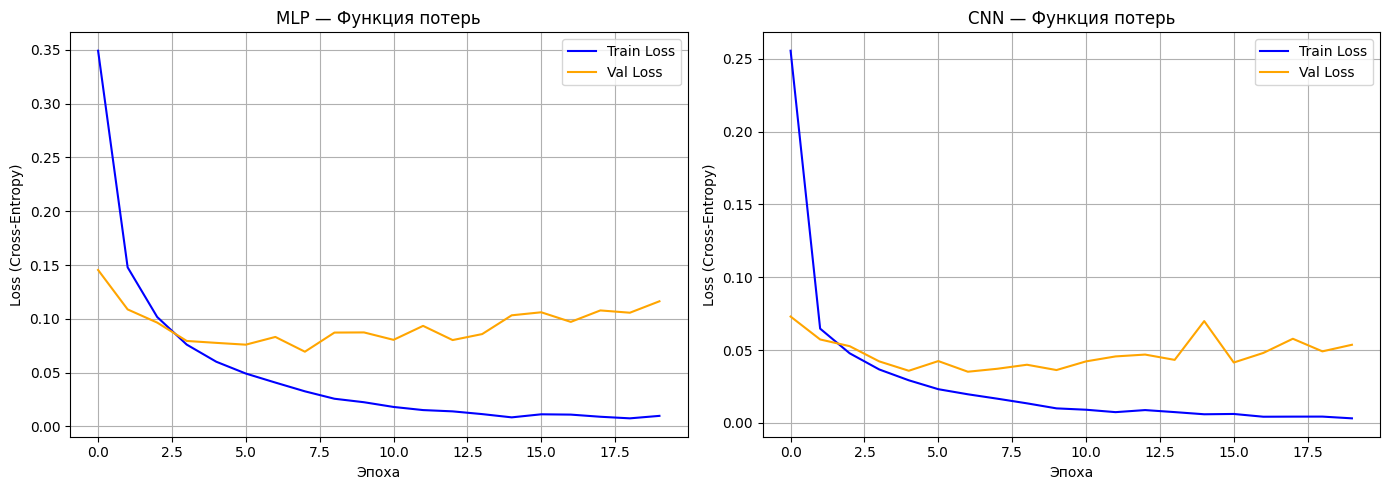

In [12]:
# Строим графики loss (функции потерь) для обеих моделей
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- MLP ---
axes[0].plot(mlp_history.history['loss'], label='Train Loss', color='blue')
axes[0].plot(mlp_history.history['val_loss'], label='Val Loss', color='orange')
axes[0].set_title('MLP — Функция потерь')
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Loss (Cross-Entropy)')
axes[0].legend()
axes[0].grid(True)

# --- CNN ---
axes[1].plot(cnn_history.history['loss'], label='Train Loss', color='blue')
axes[1].plot(cnn_history.history['val_loss'], label='Val Loss', color='orange')
axes[1].set_title('CNN — Функция потерь')
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Loss (Cross-Entropy)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

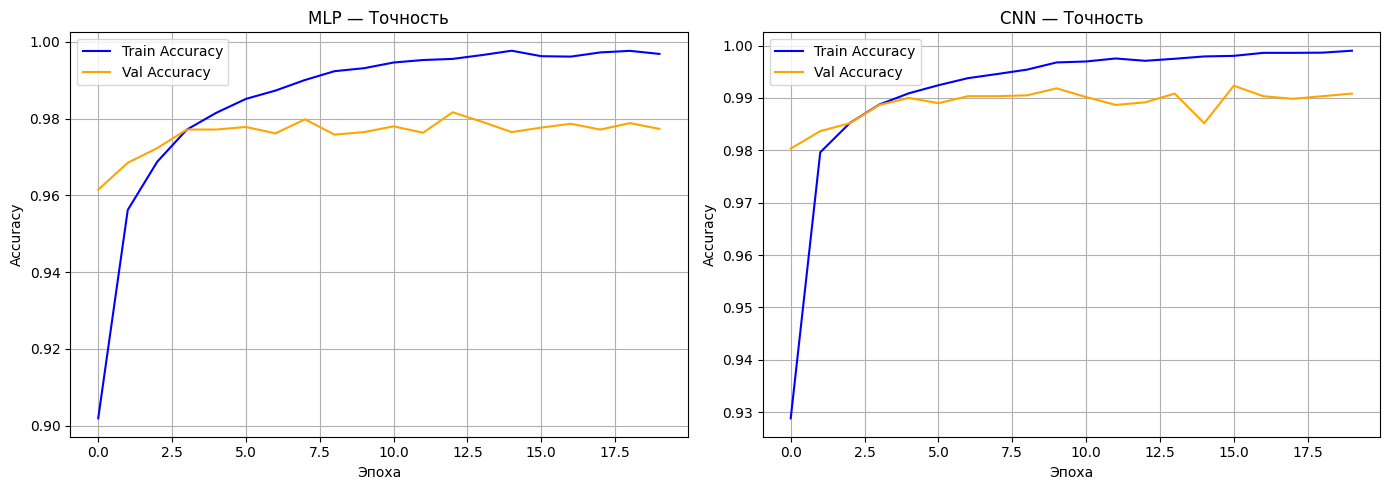

In [13]:
# Графики accuracy (точности) для обеих моделей
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- MLP ---
axes[0].plot(mlp_history.history['accuracy'], label='Train Accuracy', color='blue')
axes[0].plot(mlp_history.history['val_accuracy'], label='Val Accuracy', color='orange')
axes[0].set_title('MLP — Точность')
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# --- CNN ---
axes[1].plot(cnn_history.history['accuracy'], label='Train Accuracy', color='blue')
axes[1].plot(cnn_history.history['val_accuracy'], label='Val Accuracy', color='orange')
axes[1].set_title('CNN — Точность')
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 6. Метрики и сравнение моделей

In [14]:
# Получаем предсказания обеих моделей на тестовой выборке
# argmax берёт индекс максимальной вероятности — это и есть предсказанный класс
y_pred_mlp = np.argmax(mlp_model.predict(X_test_flat), axis=1)
y_pred_cnn = np.argmax(cnn_model.predict(X_test_cnn), axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


In [15]:
def compute_metrics(y_true, y_pred, model_name):
    """Вычисляет и выводит основные метрики классификации."""
    acc = accuracy_score(y_true, y_pred)
    # average='weighted' — взвешивает метрики по количеству примеров в каждом классе
    prec = precision_score(y_true, y_pred, average='weighted')
    rec = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    print(f"=== {model_name} ===")
    print(f"Accuracy  (доля правильных): {acc:.4f}")
    print(f"Precision (точность):        {prec:.4f}")
    print(f"Recall    (полнота):          {rec:.4f}")
    print(f"F1-score  (гармоническое среднее P и R): {f1:.4f}")
    print()

    return {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1}


mlp_metrics = compute_metrics(y_test, y_pred_mlp, "MLP")
cnn_metrics = compute_metrics(y_test, y_pred_cnn, "CNN")

=== MLP ===
Accuracy  (доля правильных): 0.9753
Precision (точность):        0.9754
Recall    (полнота):          0.9753
F1-score  (гармоническое среднее P и R): 0.9753

=== CNN ===
Accuracy  (доля правильных): 0.9915
Precision (точность):        0.9915
Recall    (полнота):          0.9915
F1-score  (гармоническое среднее P и R): 0.9915



In [16]:
# Детальный classification report для каждого класса (цифры 0-9)
print("=== MLP — Classification Report ===")
print(classification_report(y_test, y_pred_mlp))

print("\n=== CNN — Classification Report ===")
print(classification_report(y_test, y_pred_cnn))

=== MLP — Classification Report ===
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.96      0.99      0.97      1032
           3       0.96      0.98      0.97      1010
           4       0.98      0.97      0.98       982
           5       0.98      0.97      0.97       892
           6       0.98      0.98      0.98       958
           7       0.97      0.97      0.97      1028
           8       0.97      0.97      0.97       974
           9       0.98      0.95      0.96      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000


=== CNN — Classification Report ===
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       1.00      0.99      1.00      1135
     

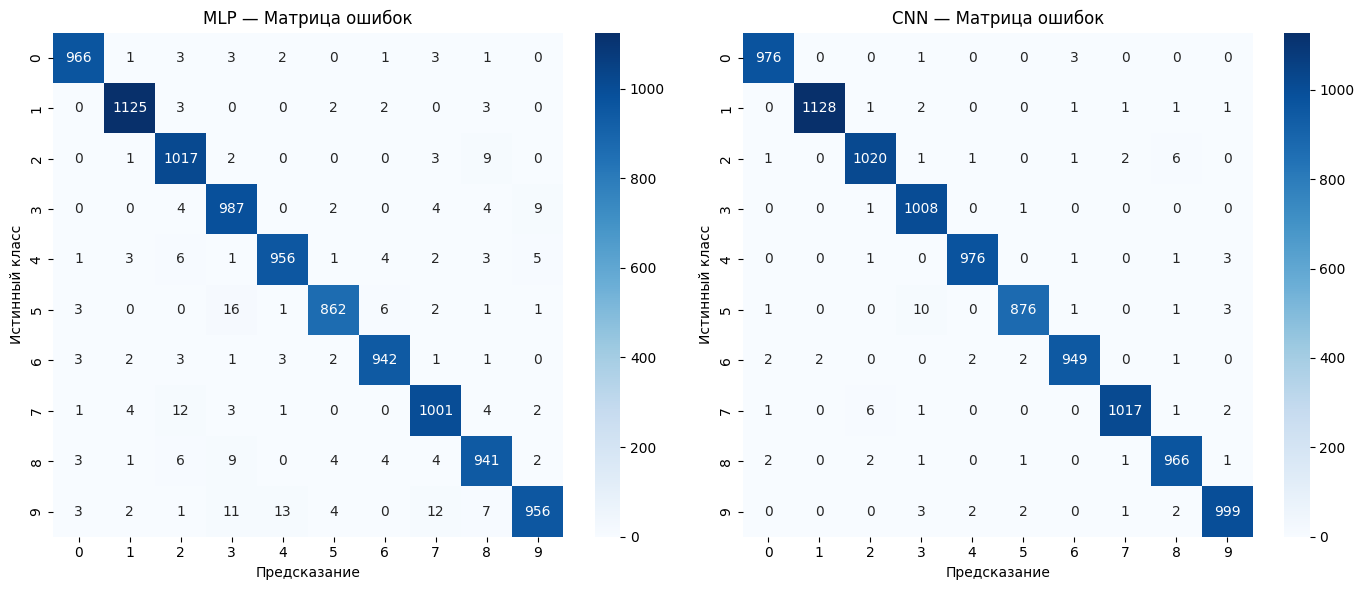

In [17]:
# Матрицы ошибок (Confusion Matrix) для обеих моделей
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, y_pred, name in zip(axes, [y_pred_mlp, y_pred_cnn], ['MLP', 'CNN']):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=range(10), yticklabels=range(10))
    ax.set_title(f'{name} — Матрица ошибок')
    ax.set_xlabel('Предсказание')
    ax.set_ylabel('Истинный класс')

plt.tight_layout()
plt.show()

In [18]:
# Сравнительная таблица метрик
import pandas as pd

comparison = pd.DataFrame({
    'MLP': mlp_metrics,
    'CNN': cnn_metrics
}).T  # транспонируем для удобного отображения

print("=== Сравнение моделей ===")
print(comparison.to_string())
print()

# Определяем лучшую модель по F1-score
if cnn_metrics['F1'] > mlp_metrics['F1']:
    print("Вывод: CNN показывает лучшие результаты, чем MLP.")
    print("Это ожидаемо, т.к. CNN учитывает пространственную структуру изображений,")
    print("а MLP теряет эту информацию при 'разворачивании' картинки в вектор.")
else:
    print("MLP показал результаты не хуже CNN на данном датасете.")

=== Сравнение моделей ===
     Accuracy  Precision  Recall        F1
MLP    0.9753   0.975400  0.9753  0.975289
CNN    0.9915   0.991527  0.9915  0.991501

Вывод: CNN показывает лучшие результаты, чем MLP.
Это ожидаемо, т.к. CNN учитывает пространственную структуру изображений,
а MLP теряет эту информацию при 'разворачивании' картинки в вектор.


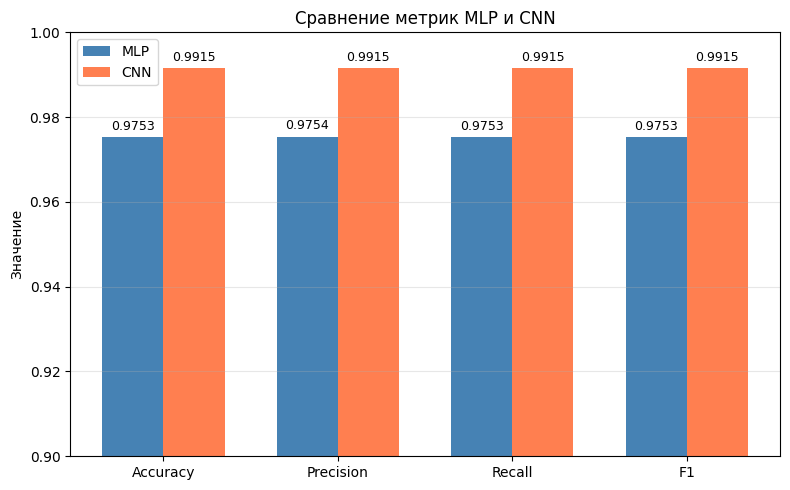

In [19]:
# Сравнительный bar-chart метрик
metrics_names = list(mlp_metrics.keys())
mlp_values = list(mlp_metrics.values())
cnn_values = list(cnn_metrics.values())

x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, mlp_values, width, label='MLP', color='steelblue')
bars2 = ax.bar(x + width/2, cnn_values, width, label='CNN', color='coral')

ax.set_ylabel('Значение')
ax.set_title('Сравнение метрик MLP и CNN')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.set_ylim(0.9, 1.0)  # масштаб для наглядности различий
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Подписи значений на столбцах
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.001,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.001,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

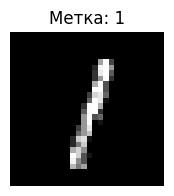

Изображение #1 (индекс 6622) | Истинная цифра: 1
────────────────────────────────────────────────────────────
  MLP: предсказание = 1 | уверенность = 0.9999 | ВЕРНО
  CNN: предсказание = 1 | уверенность = 1.0000 | ВЕРНО
  Вероятности по классам:
  Класс           MLP        CNN
    0          0.0000     0.0000
    1          0.9999     1.0000 ◄
    2          0.0000     0.0000
    3          0.0000     0.0000
    4          0.0000     0.0000
    5          0.0000     0.0000
    6          0.0000     0.0000
    7          0.0001     0.0000
    8          0.0000     0.0000
    9          0.0000     0.0000
----------------------------------------------------------------------------------------------------



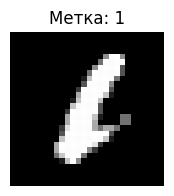

Изображение #2 (индекс 6783) | Истинная цифра: 1
────────────────────────────────────────────────────────────
  MLP: предсказание = 6 | уверенность = 0.8460 | ОШИБКА
  CNN: предсказание = 6 | уверенность = 0.5030 | ОШИБКА
  Вероятности по классам:
  Класс           MLP        CNN
    0          0.0000     0.0001
    1          0.1410     0.4967 ◄
    2          0.0001     0.0001
    3          0.0022     0.0000
    4          0.0000     0.0000
    5          0.0000     0.0000
    6          0.8460     0.5030
    7          0.0000     0.0000
    8          0.0107     0.0001
    9          0.0000     0.0000
----------------------------------------------------------------------------------------------------



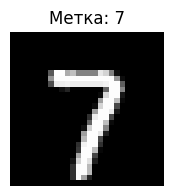

Изображение #3 (индекс 2187) | Истинная цифра: 7
────────────────────────────────────────────────────────────
  MLP: предсказание = 7 | уверенность = 1.0000 | ВЕРНО
  CNN: предсказание = 7 | уверенность = 1.0000 | ВЕРНО
  Вероятности по классам:
  Класс           MLP        CNN
    0          0.0000     0.0000
    1          0.0000     0.0000
    2          0.0000     0.0000
    3          0.0000     0.0000
    4          0.0000     0.0000
    5          0.0000     0.0000
    6          0.0000     0.0000
    7          1.0000     1.0000 ◄
    8          0.0000     0.0000
    9          0.0000     0.0000
----------------------------------------------------------------------------------------------------



In [22]:
# Выбираем 3 случайных индекса из тестовой выборки
np.random.seed(553)
indices = np.random.choice(len(X_test), 3, replace=False)

for row, idx in enumerate(indices):
    true_label = y_test[idx]

    # Показываем изображение цифры из датасета
    plt.figure(figsize=(2, 2))
    plt.imshow(X_test[idx], cmap='gray')
    plt.title(f"Метка: {true_label}")
    plt.axis('off')
    plt.show()

    # Предсказания (вектор вероятностей для каждого класса 0-9)
    mlp_probs = mlp_model.predict(X_test_flat[idx:idx+1], verbose=0)[0]
    cnn_probs = cnn_model.predict(X_test_cnn[idx:idx+1], verbose=0)[0]

    mlp_pred = np.argmax(mlp_probs)
    cnn_pred = np.argmax(cnn_probs)

    status_mlp = "ВЕРНО" if mlp_pred == true_label else "ОШИБКА"
    status_cnn = "ВЕРНО" if cnn_pred == true_label else "ОШИБКА"

    # Вывод статистики
    print(f"{'='*60}")
    print(f"Изображение #{row+1} (индекс {idx}) | Истинная цифра: {true_label}")
    print(f"{'─'*60}")
    print(f"  MLP: предсказание = {mlp_pred} | уверенность = {mlp_probs[mlp_pred]:.4f} | {status_mlp}")
    print(f"  CNN: предсказание = {cnn_pred} | уверенность = {cnn_probs[cnn_pred]:.4f} | {status_cnn}")
    print(f"  Вероятности по классам:")
    print(f"  {'Класс':<8} {'MLP':>10} {'CNN':>10}")
    for c in range(10):
        marker = " ◄" if c == true_label else ""
        print(f"    {c:<6} {mlp_probs[c]:>10.4f} {cnn_probs[c]:>10.4f}{marker}")
    print("-"*100)
    print()

